### Import bibliotek i konfiguracja

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie i przygotowanie danych

In [2]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)

# Nie dodajemy do modelu rekordów-anomalii
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])
feature_names = X.columns.tolist()

print('Rozkład klas AdoptionSpeed:')
class_dist = pd.DataFrame({
    'liczba': y.value_counts().sort_index(),
    'procent': (y.value_counts(normalize=True).sort_index() * 100).round(2),
})
class_dist.index.name = 'AdoptionSpeed'
display(class_dist)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Skalowanie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nX_train: {X_train_scaled.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test_scaled.shape}, y_test:  {y_test.shape}')

Rozkład klas AdoptionSpeed:


,liczba,procent
AdoptionSpeed,,
0,3474,23.40
1,3993,26.90
2,3209,21.62
3,4168,28.08



X_train: (11875, 20), y_train: (11875,)
X_test:  (2969, 20), y_test:  (2969,)


### Wybór parametru K

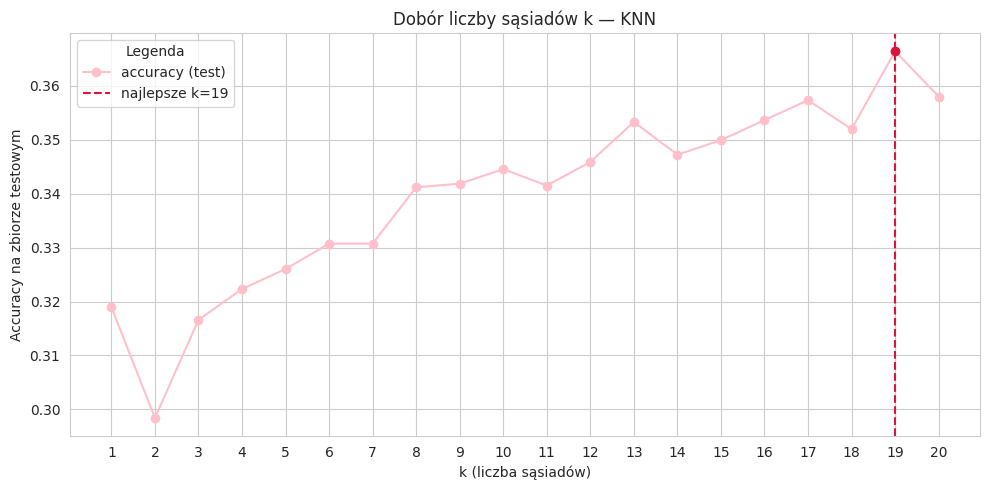

Najlepsze k na teście: 19 (accuracy=0.3665)


In [6]:
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    k_scores.append(accuracy_score(y_test, y_pred_k))

best_k = list(k_range)[int(np.argmax(k_scores))]
best_k_acc = max(k_scores)

k_results = pd.DataFrame({'k': list(k_range), 'accuracy_test': k_scores})


plt.figure(figsize=(10, 5))
plt.plot(k_results['k'], k_results['accuracy_test'], marker='o', color='pink', label='accuracy (test)')
plt.axvline(best_k, color='crimson', linestyle='--', label=f'najlepsze k={best_k}')
plt.scatter([best_k], [best_k_acc], color='crimson', zorder=5)
plt.title('Dobór liczby sąsiadów k — KNN')
plt.xlabel('k (liczba sąsiadów)')
plt.ylabel('Accuracy na zbiorze testowym')
plt.xticks(list(k_range))
plt.legend(title='Legenda')
plt.tight_layout()
plt.show()

print(f'Najlepsze k na teście: {best_k} (accuracy={best_k_acc:.4f})')

### Base KNN

Classification report (base KNN, k=5)
              precision    recall  f1-score   support

         0–7       0.29      0.40      0.34       695
        8–30       0.32      0.35      0.34       798
       31–90       0.27      0.22      0.24       642
        >100       0.43      0.32      0.37       834

    accuracy                           0.33      2969
   macro avg       0.33      0.32      0.32      2969
weighted avg       0.33      0.33      0.33      2969

Accuracy: 0.3260
F1 macro: 0.3212


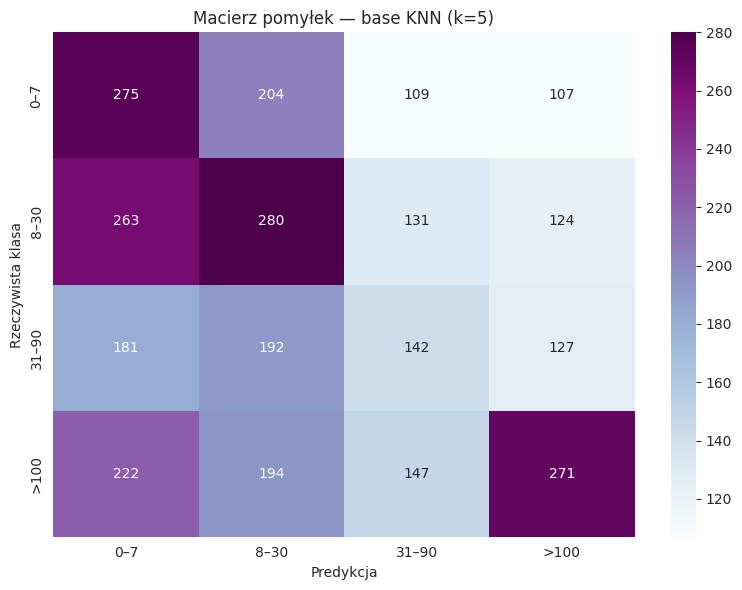

In [7]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)

y_pred_base = knn_base.predict(X_test_scaled)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')

print('Classification report (base KNN, k=5)')
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_base:.4f}')
print(f'F1 macro: {f1_base:.4f}')

cm_base = confusion_matrix(y_test, y_pred_base, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='BuPu',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — base KNN (k=5)')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Cross-validation

### Kalibracja

### Zapis modelu